<a href="https://colab.research.google.com/github/imchrisrueda/extML/blob/main/entornos_complejos/B-MC.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

En este notebook se implementan y comparan metodos tabulares en Taxi-v3:

- Monte Carlo on-policy
- Monte Carlo off-policy (Weighted Importance Sampling)
- SARSA
- Q-Learning

Lo primero es tener claro cual es la diferencia entre los enfoques:
- On-policy: el agente aprende sobre la misma politica que usa para explorar.
- Off-policy: el agente aprende una politica objetivo mientras explora con otra politica de comportamiento.

Informacion sobre este entorno la podemos encontrar [aqui](https://gymnasium.farama.org/environments/toy_text/taxi/).

Nos encontramos en un espacio discreto, donde hay exactamente 6 acciones posibles: moverse a izquierda, derecha, arriba, abajo, recoger al pasajero y dejarlo en su destino. Ademas hay 500 estados posibles: el taxi puede moverse en 5x5=25 casillas, el pasajero puede encontrarse en 5 lugares diferentes (casilla azul, verde, roja, amarilla o dentro del taxi) y el destino puede estar en 4 casillas diferentes (casilla azul, verde, roja o amarilla). Entonces, 25x5x4=500.

En cuanto a las recompensas:
- -1 por cada casilla que el taxi recorra.
- +20 si deja correctamente al pasajero en destino.
- -10 si realiza una accion ilegal.

El episodio termina cuando el taxi deja al pasajero en su destino o al llegar al limite interno del entorno.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

# Semilla
semilla = 123
np.random.seed(semilla)


In [3]:
# Para crear el entorno del taxi
import gymnasium as gym
env = gym.make('Taxi-v3')

n_episodios     = 10_000
gamma           = 0.99
epsilon_start   = 1.0
epsilon_end     = 0.05
epsilon_decay   = 0.9997
alpha_td        = 0.10

eval_every      = 250
n_eval_episodios = 50

n_estados = env.observation_space.n
n_acciones = env.action_space.n

print(f"Numero de estados: {n_estados}")
print(f"Numero de acciones: {n_acciones}")
print(f"Episodios: {n_episodios}")
print(f"Gamma: {gamma}")
print(f"Epsilon: {epsilon_start} -> {epsilon_end} (decay={epsilon_decay})")
print(f"Alpha TD: {alpha_td}")


Numero de estados: 500
Numero de acciones: 6
Episodios: 10000
Gamma: 0.99
Epsilon: 1.0 -> 0.05 (decay=0.9997)
Alpha TD: 0.1


In [4]:
def epsilon_greedy(Q, estado, epsilon, n_acciones):
    if np.random.random() < epsilon:
        return np.random.randint(n_acciones)
    return int(np.argmax(Q[estado]))


def evaluar_greedy(env, Q, n_eval=50):
    recompensas = []
    for ep in range(n_eval):
        estado, _ = env.reset(seed=10_000 + ep)
        done = False
        total = 0.0
        while not done:
            accion = int(np.argmax(Q[estado]))
            estado, recompensa, terminado, truncado, _ = env.step(accion)
            total += recompensa
            done = terminado or truncado
        recompensas.append(total)
    return float(np.mean(recompensas)), float(np.std(recompensas))


def mc_on_policy(env, n_episodios, gamma, epsilon_start, epsilon_end, epsilon_decay,
                 eval_every=250, n_eval=50):
    n_estados = env.observation_space.n
    n_acciones = env.action_space.n

    Q = np.zeros((n_estados, n_acciones))
    N = np.zeros((n_estados, n_acciones))

    epsilon = epsilon_start
    recompensas = []
    longitudes = []
    eval_rewards = []
    eval_stds = []
    eval_eps = []
    eps_hist = []

    for episodio in range(n_episodios):
        estado, _ = env.reset(seed=np.random.randint(1_000_000))
        done = False
        episode = []
        ep_reward = 0.0
        ep_len = 0

        while not done:
            accion = epsilon_greedy(Q, estado, epsilon, n_acciones)
            siguiente_estado, recompensa, terminado, truncado, _ = env.step(accion)
            episode.append((estado, accion, recompensa))
            estado = siguiente_estado
            done = terminado or truncado
            ep_reward += recompensa
            ep_len += 1

        G = 0.0
        visited = set()
        for estado, accion, recompensa in reversed(episode):
            G = gamma * G + recompensa
            if (estado, accion) in visited:
                continue
            visited.add((estado, accion))
            N[estado, accion] += 1
            Q[estado, accion] += (G - Q[estado, accion]) / N[estado, accion]

        recompensas.append(ep_reward)
        longitudes.append(ep_len)
        eps_hist.append(epsilon)

        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        if (episodio + 1) % eval_every == 0:
            media, std = evaluar_greedy(env, Q, n_eval)
            eval_rewards.append(media)
            eval_stds.append(std)
            eval_eps.append(episodio + 1)

    return Q, recompensas, longitudes, eval_rewards, eval_stds, eval_eps, eps_hist


def mc_off_policy_weighted(env, n_episodios, gamma, epsilon_start, epsilon_end, epsilon_decay,
                           eval_every=250, n_eval=50):
    n_estados = env.observation_space.n
    n_acciones = env.action_space.n

    Q = np.zeros((n_estados, n_acciones))
    C = np.zeros((n_estados, n_acciones))

    epsilon = epsilon_start
    recompensas = []
    longitudes = []
    eval_rewards = []
    eval_stds = []
    eval_eps = []
    eps_hist = []

    for episodio in range(n_episodios):
        estado, _ = env.reset(seed=np.random.randint(1_000_000))
        done = False
        episode = []
        ep_reward = 0.0
        ep_len = 0

        while not done:
            accion = epsilon_greedy(Q, estado, epsilon, n_acciones)
            siguiente_estado, recompensa, terminado, truncado, _ = env.step(accion)
            episode.append((estado, accion, recompensa))
            estado = siguiente_estado
            done = terminado or truncado
            ep_reward += recompensa
            ep_len += 1

        G = 0.0
        W = 1.0
        for estado, accion, recompensa in reversed(episode):
            G = gamma * G + recompensa
            C[estado, accion] += W
            Q[estado, accion] += (W / C[estado, accion]) * (G - Q[estado, accion])

            accion_greedy = int(np.argmax(Q[estado]))
            if accion != accion_greedy:
                break

            prob_b = (1.0 - epsilon) + (epsilon / n_acciones)
            W *= 1.0 / prob_b

        recompensas.append(ep_reward)
        longitudes.append(ep_len)
        eps_hist.append(epsilon)

        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        if (episodio + 1) % eval_every == 0:
            media, std = evaluar_greedy(env, Q, n_eval)
            eval_rewards.append(media)
            eval_stds.append(std)
            eval_eps.append(episodio + 1)

    return Q, recompensas, longitudes, eval_rewards, eval_stds, eval_eps, eps_hist


def sarsa_tabular(env, n_episodios, alpha, gamma, epsilon_start, epsilon_end, epsilon_decay,
                  eval_every=250, n_eval=50):
    n_estados = env.observation_space.n
    n_acciones = env.action_space.n

    Q = np.zeros((n_estados, n_acciones))

    epsilon = epsilon_start
    recompensas = []
    longitudes = []
    eval_rewards = []
    eval_stds = []
    eval_eps = []
    eps_hist = []

    for episodio in range(n_episodios):
        estado, _ = env.reset(seed=np.random.randint(1_000_000))
        accion = epsilon_greedy(Q, estado, epsilon, n_acciones)
        done = False
        ep_reward = 0.0
        ep_len = 0

        while not done:
            siguiente_estado, recompensa, terminado, truncado, _ = env.step(accion)
            done = terminado or truncado

            if done:
                td_target = recompensa
            else:
                siguiente_accion = epsilon_greedy(Q, siguiente_estado, epsilon, n_acciones)
                td_target = recompensa + gamma * Q[siguiente_estado, siguiente_accion]

            Q[estado, accion] += alpha * (td_target - Q[estado, accion])

            ep_reward += recompensa
            ep_len += 1

            if not done:
                estado, accion = siguiente_estado, siguiente_accion

        recompensas.append(ep_reward)
        longitudes.append(ep_len)
        eps_hist.append(epsilon)

        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        if (episodio + 1) % eval_every == 0:
            media, std = evaluar_greedy(env, Q, n_eval)
            eval_rewards.append(media)
            eval_stds.append(std)
            eval_eps.append(episodio + 1)

    return Q, recompensas, longitudes, eval_rewards, eval_stds, eval_eps, eps_hist


def q_learning_tabular(env, n_episodios, alpha, gamma, epsilon_start, epsilon_end, epsilon_decay,
                       eval_every=250, n_eval=50):
    n_estados = env.observation_space.n
    n_acciones = env.action_space.n

    Q = np.zeros((n_estados, n_acciones))

    epsilon = epsilon_start
    recompensas = []
    longitudes = []
    eval_rewards = []
    eval_stds = []
    eval_eps = []
    eps_hist = []

    for episodio in range(n_episodios):
        estado, _ = env.reset(seed=np.random.randint(1_000_000))
        done = False
        ep_reward = 0.0
        ep_len = 0

        while not done:
            accion = epsilon_greedy(Q, estado, epsilon, n_acciones)
            siguiente_estado, recompensa, terminado, truncado, _ = env.step(accion)
            done = terminado or truncado

            td_target = recompensa if done else recompensa + gamma * np.max(Q[siguiente_estado])
            Q[estado, accion] += alpha * (td_target - Q[estado, accion])

            estado = siguiente_estado
            ep_reward += recompensa
            ep_len += 1

        recompensas.append(ep_reward)
        longitudes.append(ep_len)
        eps_hist.append(epsilon)

        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        if (episodio + 1) % eval_every == 0:
            media, std = evaluar_greedy(env, Q, n_eval)
            eval_rewards.append(media)
            eval_stds.append(std)
            eval_eps.append(episodio + 1)

    return Q, recompensas, longitudes, eval_rewards, eval_stds, eval_eps, eps_hist


### Monte Carlo on-policy


In [5]:
print('Entrenando MC on-policy...')
Q_on, recompensas_por_episodio_on, longitud_por_episodio_on, eval_on, std_on, eval_eps_on, epsilon_hist_on = mc_on_policy(
    env,
    n_episodios=n_episodios,
    gamma=gamma,
    epsilon_start=epsilon_start,
    epsilon_end=epsilon_end,
    epsilon_decay=epsilon_decay,
    eval_every=eval_every,
    n_eval=n_eval_episodios,
)
print(f"MC on-policy final eval: {eval_on[-1]:.2f} +/- {std_on[-1]:.2f}")


Entrenando MC on-policy...
MC on-policy final eval: -424.04 +/- 688.94


### Monte Carlo off-policy (Weighted IS)


In [6]:
print('Entrenando MC off-policy weighted...')
Q_off, recompensas_por_episodio_off, longitud_por_episodio_off, eval_off, std_off, eval_eps_off, epsilon_hist_off = mc_off_policy_weighted(
    env,
    n_episodios=n_episodios,
    gamma=gamma,
    epsilon_start=epsilon_start,
    epsilon_end=epsilon_end,
    epsilon_decay=epsilon_decay,
    eval_every=eval_every,
    n_eval=n_eval_episodios,
)
print(f"MC off-policy weighted final eval: {eval_off[-1]:.2f} +/- {std_off[-1]:.2f}")


Entrenando MC off-policy weighted...
MC off-policy weighted final eval: -0.92 +/- 40.74


In [7]:
print('Entrenando SARSA...')
Q_sarsa, recompensas_por_episodio_sarsa, longitud_por_episodio_sarsa, eval_sarsa, std_sarsa, eval_eps_sarsa, epsilon_hist_sarsa = sarsa_tabular(
    env,
    n_episodios=n_episodios,
    alpha=alpha_td,
    gamma=gamma,
    epsilon_start=epsilon_start,
    epsilon_end=epsilon_end,
    epsilon_decay=epsilon_decay,
    eval_every=eval_every,
    n_eval=n_eval_episodios,
)
print(f"SARSA final eval: {eval_sarsa[-1]:.2f} +/- {std_sarsa[-1]:.2f}")

print('Entrenando Q-Learning...')
Q_ql, recompensas_por_episodio_ql, longitud_por_episodio_ql, eval_ql, std_ql, eval_eps_ql, epsilon_hist_ql = q_learning_tabular(
    env,
    n_episodios=n_episodios,
    alpha=alpha_td,
    gamma=gamma,
    epsilon_start=epsilon_start,
    epsilon_end=epsilon_end,
    epsilon_decay=epsilon_decay,
    eval_every=eval_every,
    n_eval=n_eval_episodios,
)
print(f"Q-Learning final eval: {eval_ql[-1]:.2f} +/- {std_ql[-1]:.2f}")


Entrenando SARSA...
SARSA final eval: 8.18 +/- 2.56
Entrenando Q-Learning...
Q-Learning final eval: 8.22 +/- 2.52


## Graficos comparativos


/tmp/ipykernel_273256/2672161476.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


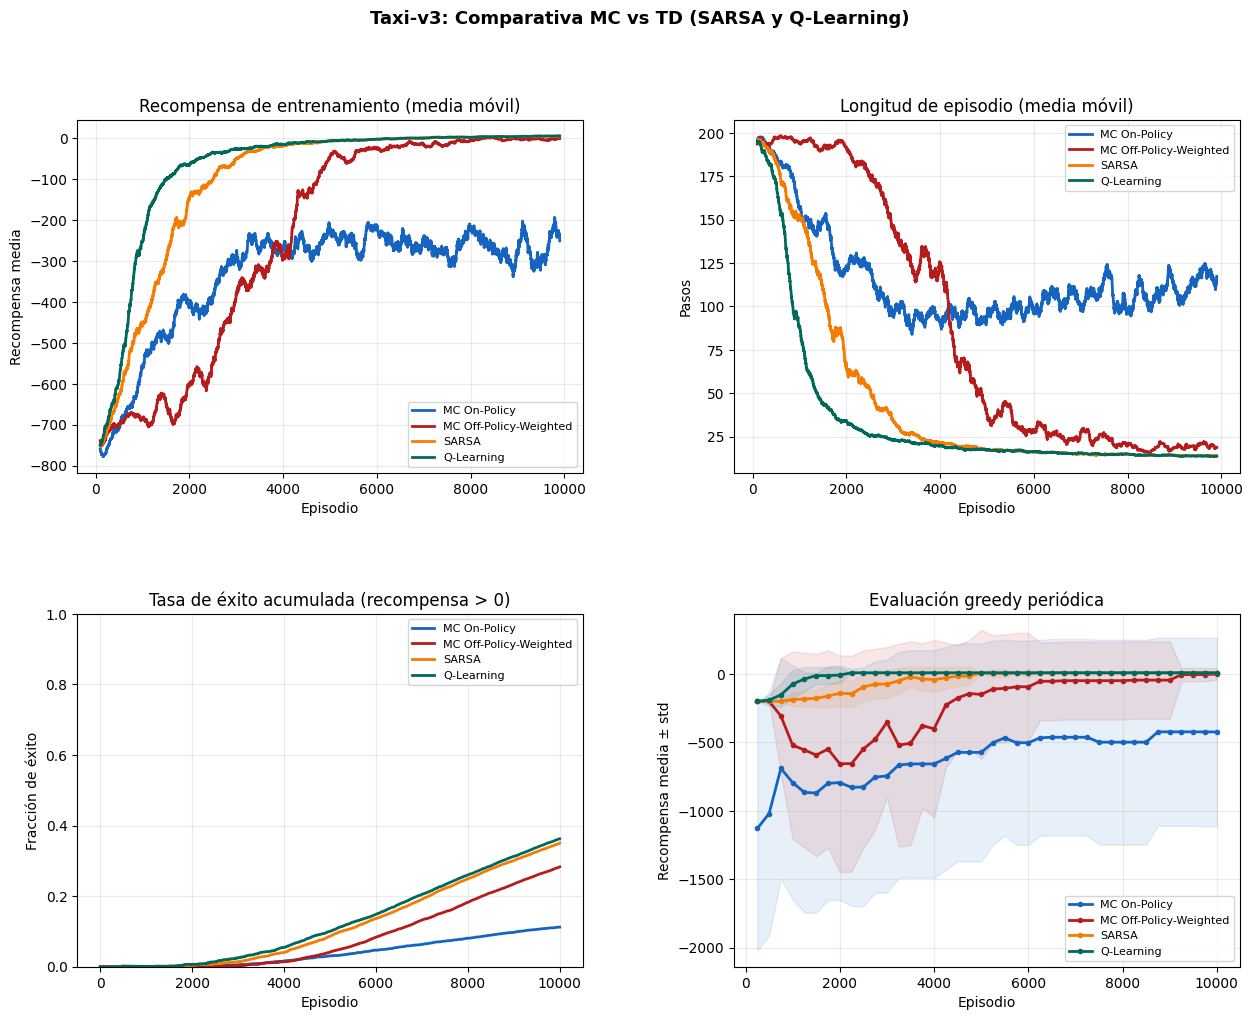


RESUMEN COMPARATIVO
                        Recompensa media últimos 1000  Longitud media últimos 1000  Éxito últimos 1000  Eval final  Eval final std  Mejor eval
Método                                                                                                                                        
MC On-Policy                                 -265.506                      113.064               0.244    -424.040         688.941    -423.320
MC Off-Policy-Weighted                         -1.975                       19.369               0.720      -0.920          40.743      -0.920
SARSA                                           4.748                       14.119               0.795       8.180           2.559       8.180
Q-Learning                                      5.170                       13.769               0.813       8.220           2.524       8.220


In [8]:
def media_movil(valores, ventana=200):
    return np.convolve(valores, np.ones(ventana) / ventana, mode='valid')


VENTANA = 200
metodos = [
    ('MC On-Policy', recompensas_por_episodio_on, longitud_por_episodio_on, eval_on, std_on, eval_eps_on, '#1565C0'),
    ('MC Off-Policy-Weighted', recompensas_por_episodio_off, longitud_por_episodio_off, eval_off, std_off, eval_eps_off, '#B71C1C'),
    ('SARSA', recompensas_por_episodio_sarsa, longitud_por_episodio_sarsa, eval_sarsa, std_sarsa, eval_eps_sarsa, '#F57C00'),
    ('Q-Learning', recompensas_por_episodio_ql, longitud_por_episodio_ql, eval_ql, std_ql, eval_eps_ql, '#00695C'),
]

fig = plt.figure(figsize=(15, 11))
fig.suptitle('Taxi-v3: Comparativa MC vs TD (SARSA y Q-Learning)', fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# 1) Recompensa media de entrenamiento
ax1 = fig.add_subplot(gs[0, 0])
for nombre, rewards, _, _, _, _, color in metodos:
    suav = media_movil(rewards, VENTANA)
    x = np.arange(VENTANA // 2, len(suav) + VENTANA // 2)
    ax1.plot(x, suav, lw=2, color=color, label=nombre)
ax1.set_title('Recompensa de entrenamiento (media móvil)')
ax1.set_xlabel('Episodio')
ax1.set_ylabel('Recompensa media')
ax1.grid(alpha=0.25)
ax1.legend(fontsize=8)

# 2) Longitud media de episodio
ax2 = fig.add_subplot(gs[0, 1])
for nombre, _, longitudes, _, _, _, color in metodos:
    suav = media_movil(longitudes, VENTANA)
    x = np.arange(VENTANA // 2, len(suav) + VENTANA // 2)
    ax2.plot(x, suav, lw=2, color=color, label=nombre)
ax2.set_title('Longitud de episodio (media móvil)')
ax2.set_xlabel('Episodio')
ax2.set_ylabel('Pasos')
ax2.grid(alpha=0.25)
ax2.legend(fontsize=8)

# 3) Tasa de éxito acumulada
ax3 = fig.add_subplot(gs[1, 0])
for nombre, rewards, _, _, _, _, color in metodos:
    exitos = np.array(rewards) > 0
    tasa = np.cumsum(exitos) / (np.arange(len(exitos)) + 1)
    ax3.plot(tasa, lw=2, color=color, label=nombre)
ax3.set_title('Tasa de éxito acumulada (recompensa > 0)')
ax3.set_xlabel('Episodio')
ax3.set_ylabel('Fracción de éxito')
ax3.set_ylim(0, 1)
ax3.grid(alpha=0.25)
ax3.legend(fontsize=8)

# 4) Evaluacion greedy periodica
ax4 = fig.add_subplot(gs[1, 1])
for nombre, _, _, eval_r, eval_std, eval_eps, color in metodos:
    eval_r = np.array(eval_r)
    eval_std = np.array(eval_std)
    ax4.plot(eval_eps, eval_r, lw=2, color=color, marker='o', ms=3, label=nombre)
    ax4.fill_between(eval_eps, eval_r - eval_std, eval_r + eval_std, color=color, alpha=0.10)
ax4.set_title('Evaluación greedy periódica')
ax4.set_xlabel('Episodio')
ax4.set_ylabel('Recompensa media ± std')
ax4.grid(alpha=0.25)
ax4.legend(fontsize=8)

plt.tight_layout()
plt.show()


# Tabla resumen final
ultimos = 1000
filas = []
for nombre, rewards, longitudes, eval_r, eval_std, _, _ in metodos:
    filas.append({
        'Método': nombre,
        'Recompensa media últimos 1000': np.mean(rewards[-ultimos:]),
        'Longitud media últimos 1000': np.mean(longitudes[-ultimos:]),
        'Éxito últimos 1000': np.mean(np.array(rewards[-ultimos:]) > 0),
        'Eval final': eval_r[-1],
        'Eval final std': eval_std[-1],
        'Mejor eval': np.max(eval_r),
    })

df = pd.DataFrame(filas).set_index('Método')
print('\n' + '=' * 100)
print('RESUMEN COMPARATIVO')
print('=' * 100)
print(df.to_string(float_format=lambda x: f'{x:0.3f}'))
print('=' * 100)


Conclusiones ajustadas a los resultados obtenidos en esta ejecucion (10.000 episodios):

**Ranking final por evaluacion greedy**
1. Q-Learning: 8.22 +/- 2.52
2. SARSA: 8.18 +/- 2.56
3. MC Off-Policy Weighted: -0.92 +/- 40.74
4. MC On-Policy: -424.04 +/- 688.94

**Lectura de resultados**
- En este experimento, los metodos TD (Q-Learning y SARSA) superan claramente a Monte Carlo en Taxi-v3.
- Q-Learning queda ligeramente por encima de SARSA, tanto en eval final como en metricas de entrenamiento:
  - Reward medio ultimos 1000: 5.17 (QL) vs 4.75 (SARSA)
  - Longitud media ultimos 1000: 13.77 (QL) vs 14.12 (SARSA)
  - Tasa de exito ultimos 1000: 81.3% (QL) vs 79.5% (SARSA)
- MC Off-Policy Weighted mejora mucho frente a MC On-Policy, pero no alcanza el nivel de TD en esta configuracion.
- MC On-Policy muestra rendimiento muy bajo y alta varianza final en esta corrida, lo que sugiere que con estos hiperparametros no converge a una politica competitiva.

**Conclusion tecnica**
- Para este entorno y esta configuracion, la mejor opcion practica es Q-Learning, con SARSA como alternativa muy cercana y estable.
- Monte Carlo queda por detras porque aprende al final de cada episodio, mientras que TD corrige en cada paso (bootstrap), acelerando la mejora en Taxi-v3.

Nota: estas cifras corresponden a una corrida con una semilla fija (`semilla=123`). Para el informe final, conviene validar con varias semillas y reportar media +/- desviacion entre semillas.
